# 0 Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import re

import pandas as pd

from src.suporte import funcoes_suporte as fs

## 0.1 Funções Suporte

In [38]:
fs.jupyter_settings(altura = 10, largura = 12, fonte = 8)
fs.supressao_notacao(casa_decimal = 4)

# 0.2 Load Data

In [3]:
df_raw = pd.read_csv('../data/raw/data.csv', encoding_errors="replace")
df_raw.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
499397,578667,22845,VINTAGE CREAM CAT FOOD CONTAINER,1,11/24/2011 17:10,6.35,15514.00,United Kingdom
190848,553211,22558,CLOTHES PEGS RETROSPOT PACK 24,12,5/16/2011 9:40,1.65,15358.00,United Kingdom
450941,575177,22994,TRAVEL CARD WALLET RETROSPOT,2,11/8/2011 18:41,0.83,NaN,United Kingdom
382245,569898,23158,SET OF 5 LUCKY CAT MAGNETS,2,10/6/2011 16:08,4.13,NaN,United Kingdom
227593,556886,15058B,PINK POLKADOT GARDEN PARASOL,2,6/15/2011 12:34,7.95,12624.00,France


# 1.0 Descrição dos Dados

## 1.1 Rename Columns

In [4]:
df_raw.columns = [fs.to_snake_case(col) for col in df_raw.columns]
df_raw.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


## 1.2 Data Info

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   invoice_no    541909 non-null  object 
 1   stock_code    541909 non-null  object 
 2   description   540455 non-null  object 
 3   quantity      541909 non-null  int64  
 4   invoice_date  541909 non-null  object 
 5   unit_price    541909 non-null  float64
 6   customer_id   406829 non-null  float64
 7   country       541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 1.2.1 NA

In [6]:
df_raw.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

In [7]:
df_raw = df_raw.dropna(subset=["description", "customer_id"])

## 1.3 Change Dtypes

In [8]:
df_raw["invoice_date"] = pd.to_datetime(df_raw["invoice_date"], format="%m/%d/%Y %H:%M").dt.normalize()

df_raw['customer_id'] = df_raw['customer_id'].astype(int)
df_raw.sample()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
211275,555353,22776,SWEETHEART CAKESTAND 3 TIER,1,2011-06-02,9.95,16928,United Kingdom


In [9]:
df_raw.dtypes

invoice_no              object
stock_code              object
description             object
quantity                 int64
invoice_date    datetime64[ns]
unit_price             float64
customer_id              int64
country                 object
dtype: object

## 1.4 Estatística Descritiva Simples

In [10]:
var_num = df_raw.select_dtypes(include = ['int64','float64'])
var_cat = df_raw.select_dtypes(exclude = ['int64','float64'])

### 1.4.1 Análise Numérica

In [11]:
fs.estatistica_descritiva(var_num)

,variaveis,minimo,maximo,range,media,mediana,desvio_padrao,iqr,assimetria,curtosis,cv
0,quantity,-80995.00,80995.00,161990.00,12.06,5.00,248.69,10.00,0.18,94317.56,20.62
1,unit_price,0.00,38970.00,38970.00,3.46,1.95,69.32,2.50,452.22,246924.54,20.03
2,customer_id,12346.00,18287.00,5941.00,15287.69,15152.00,1713.60,2838.00,0.03,-1.18,0.11


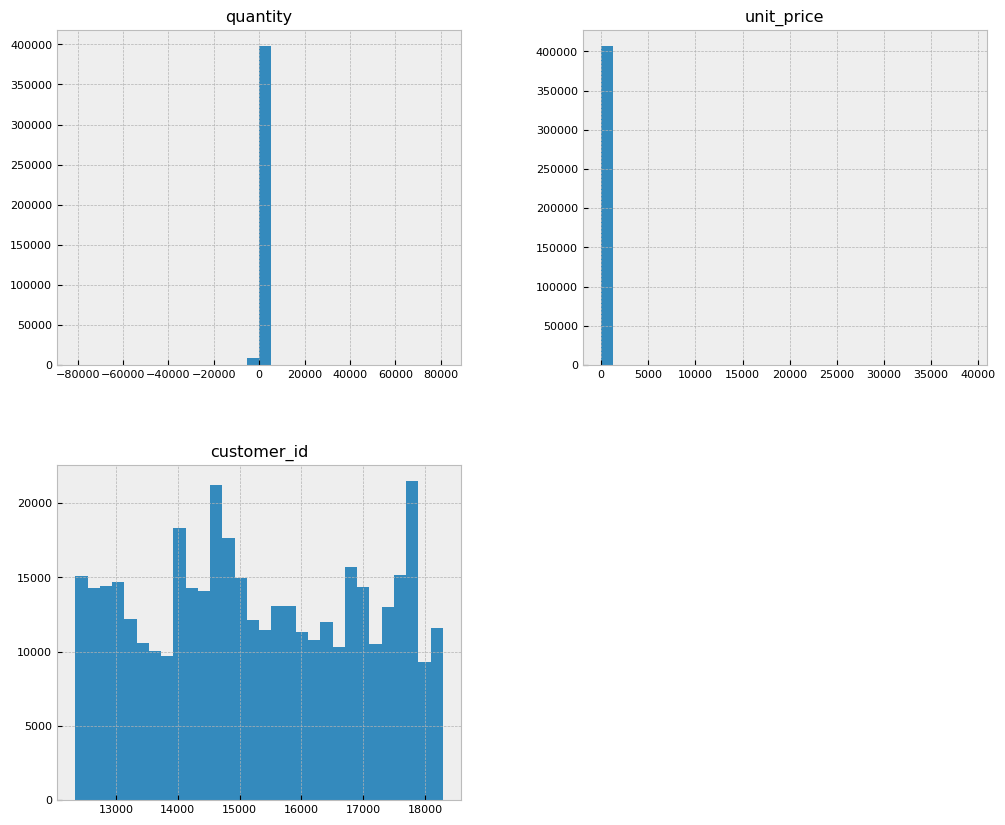

In [12]:
var_num.hist(bins=30);

#### Resultado da Análise Numérica

Estudar perguntas em outro momento:
- quantity negativa, seriam devoluções?
- unit_price, tem produtos Zerados. Que tipo de produto é esse que está zerado? Veio de uma promoção?

### 1.4.2 Análise categórica

Atributo: invoice_no
Total de Valores Únicos: 22190
Total de Valores não Nulos: 406829
Total de Valores Nulos: 0
Porcentagem Valores Nulos (%) : 0.00%

Valores Descritos: ['536365', '536366', '536367', '536368', '536369', '536370', '536371', '536372', '536373', '536374', '536375', '536376', '536377', '536378', '536380', '536381', '536382', '536384', '536385', '536386', '536387', '536388', '536389', '536390', '536392', '536393', '536394', '536395', '536396', '536397', '536398', '536399', '536400', '536401', '536402', '536403', '536404', '536405', '536406', '536407', '536408', '536409', '536412', '536415', '536416', '536420', '536423', '536425', '536437', '536446', '536460', '536463', '536464', '536466', '536477', '536488', '536500', '536502', '536508', '536514', '536520', '536521', '536522', '536523', '536524', '536525', '536526', '536527', '536528', '536529', '536530', '536531', '536532', '536533', '536534', '536535', '536536', '536537', '536538', '536539', '536540', '536541', '536542'

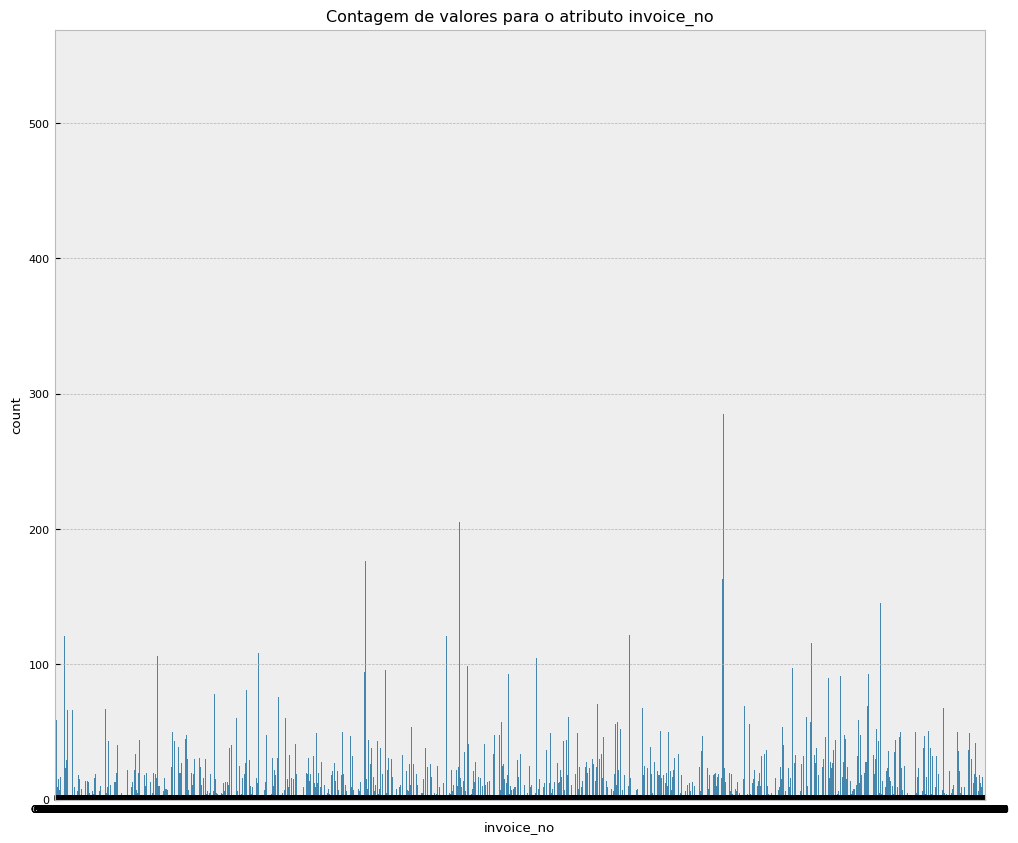

----------------------------------------------------------------

Atributo: stock_code
Total de Valores Únicos: 3684
Total de Valores não Nulos: 406829
Total de Valores Nulos: 0
Porcentagem Valores Nulos (%) : 0.00%

Valores Descritos: ['10002', '10080', '10120', '10123C', '10124A', '10124G', '10125', '10133', '10135', '11001', '15030', '15034', '15036', '15039', '15044A', '15044B', '15044C', '15044D', '15056BL', '15056N', '15056P', '15058A', '15058B', '15058C', '15060B', '16008', '16010', '16011', '16012', '16014', '16015', '16016', '16020C', '16033', '16043', '16045', '16046', '16048', '16049', '16052', '16054', '16151A', '16156L', '16156S', '16161G', '16161M', '16161P', '16161U', '16162L', '16162M', '16168M', '16169E', '16169K', '16169M', '16169N', '16169P', '16202A', '16202B', '16202E', '16206B', '16207A', '16207B', '16216', '16218', '16219', '16225', '16235', '16236', '16237', '16238', '16244B', '16248B', '16254', '16258A', '16259', '17001', '17003', '17007B', '17011F', '17012A', 

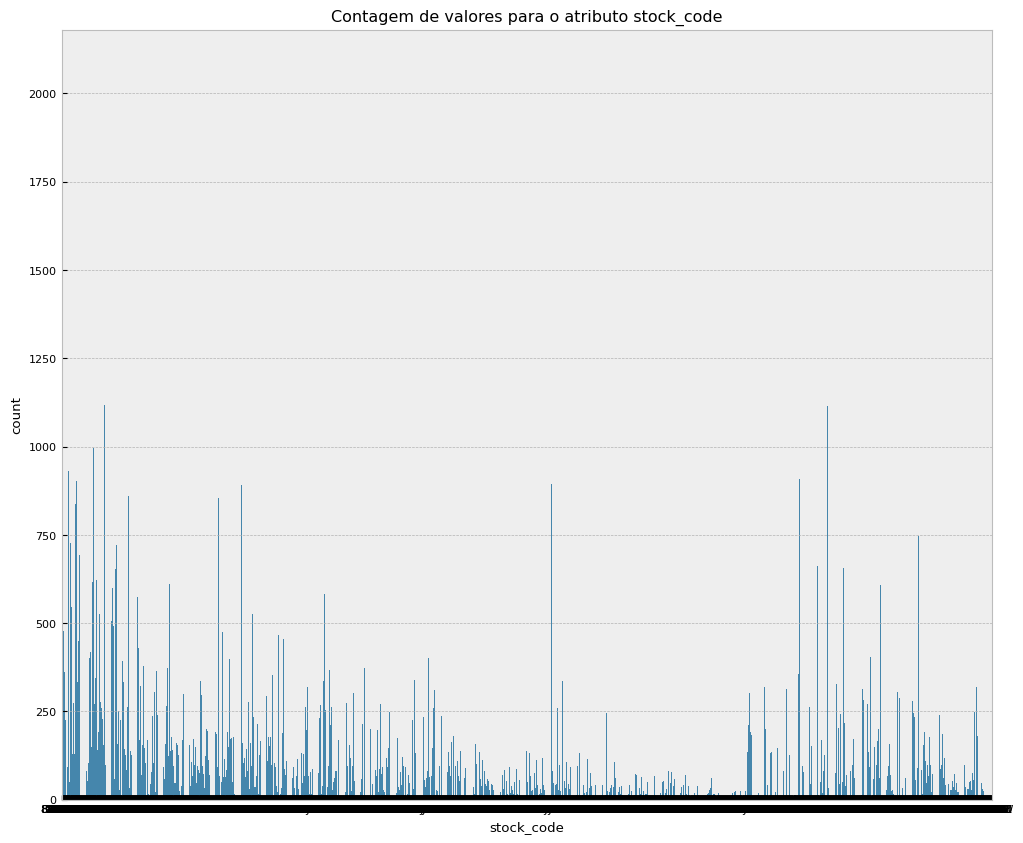

----------------------------------------------------------------

Atributo: description
Total de Valores Únicos: 3896
Total de Valores não Nulos: 406829
Total de Valores Nulos: 0
Porcentagem Valores Nulos (%) : 0.00%

Valores Descritos: [' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG LARGE", ' DOLLY GIRL BEAKER', ' I LOVE LONDON MINI BACKPACK', ' I LOVE LONDON MINI RUCKSACK', ' NINE DRAWER OFFICE TIDY', ' OVAL WALL MIRROR DIAMANTE ', ' RED SPOT GIFT BAG LARGE', ' SET 2 TEA TOWELS I LOVE LONDON ', ' SPACEBOY BABY GIFT SET', ' TOADSTOOL BEDSIDE LIGHT ', ' TRELLIS COAT RACK', '10 COLOUR SPACEBOY PEN', '12 COLOURED PARTY BALLOONS', '12 DAISY PEGS IN WOOD BOX', '12 EGG HOUSE PAINTED WOOD', '12 HANGING EGGS HAND PAINTED', '12 IVORY ROSE PEG PLACE SETTINGS', '12 MESSAGE CARDS WITH ENVELOPES', '12 PENCIL SMALL TUBE WOODLAND', '12 PENCILS SMALL TUBE RED RETROSPOT', '12 PENCILS SMALL TUBE SKULL', '12 PENCILS TALL TUBE POSY', '12 PENCILS TALL TUBE RED RETROSPOT', '12 PENCILS TALL TUB

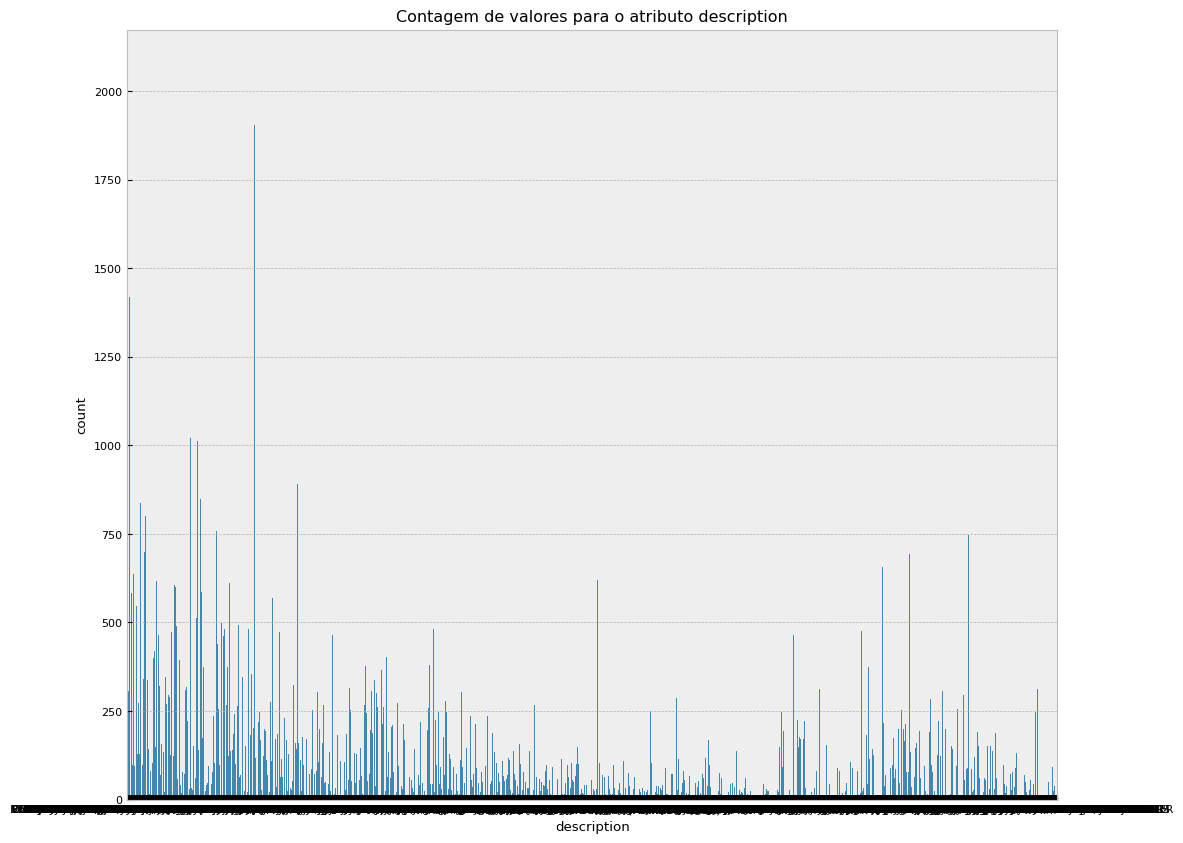

----------------------------------------------------------------

Atributo: invoice_date
Total de Valores Únicos: 305
Total de Valores não Nulos: 406829
Total de Valores Nulos: 0
Porcentagem Valores Nulos (%) : 0.00%

Valores Descritos: [Timestamp('2010-12-01 00:00:00'), Timestamp('2010-12-02 00:00:00'), Timestamp('2010-12-03 00:00:00'), Timestamp('2010-12-05 00:00:00'), Timestamp('2010-12-06 00:00:00'), Timestamp('2010-12-07 00:00:00'), Timestamp('2010-12-08 00:00:00'), Timestamp('2010-12-09 00:00:00'), Timestamp('2010-12-10 00:00:00'), Timestamp('2010-12-12 00:00:00'), Timestamp('2010-12-13 00:00:00'), Timestamp('2010-12-14 00:00:00'), Timestamp('2010-12-15 00:00:00'), Timestamp('2010-12-16 00:00:00'), Timestamp('2010-12-17 00:00:00'), Timestamp('2010-12-19 00:00:00'), Timestamp('2010-12-20 00:00:00'), Timestamp('2010-12-21 00:00:00'), Timestamp('2010-12-22 00:00:00'), Timestamp('2010-12-23 00:00:00'), Timestamp('2011-01-04 00:00:00'), Timestamp('2011-01-05 00:00:00'), Timestamp('201

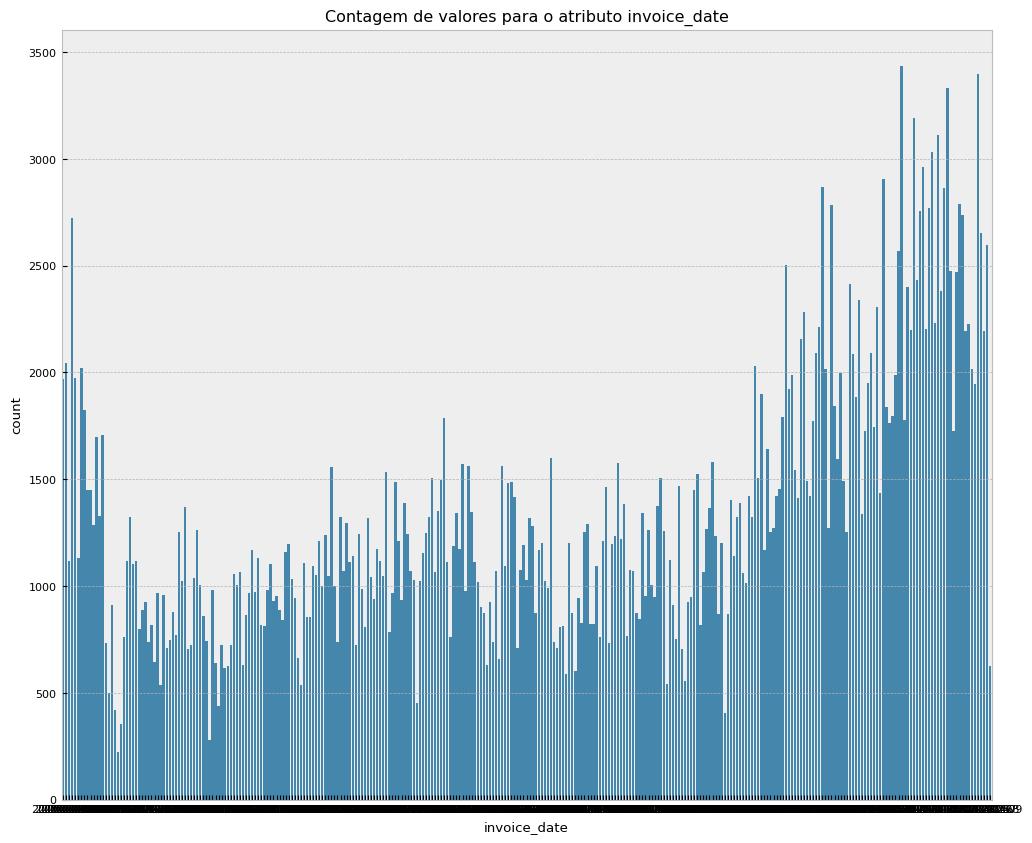

----------------------------------------------------------------

Atributo: country
Total de Valores Únicos: 37
Total de Valores não Nulos: 406829
Total de Valores Nulos: 0
Porcentagem Valores Nulos (%) : 0.00%

Valores Descritos: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Canada', 'Channel Islands', 'Cyprus', 'Czech Republic', 'Denmark', 'EIRE', 'European Community', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Israel', 'Italy', 'Japan', 'Lebanon', 'Lithuania', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'RSA', 'Saudi Arabia', 'Singapore', 'Spain', 'Sweden', 'Switzerland', 'USA', 'United Arab Emirates', 'United Kingdom', 'Unspecified']



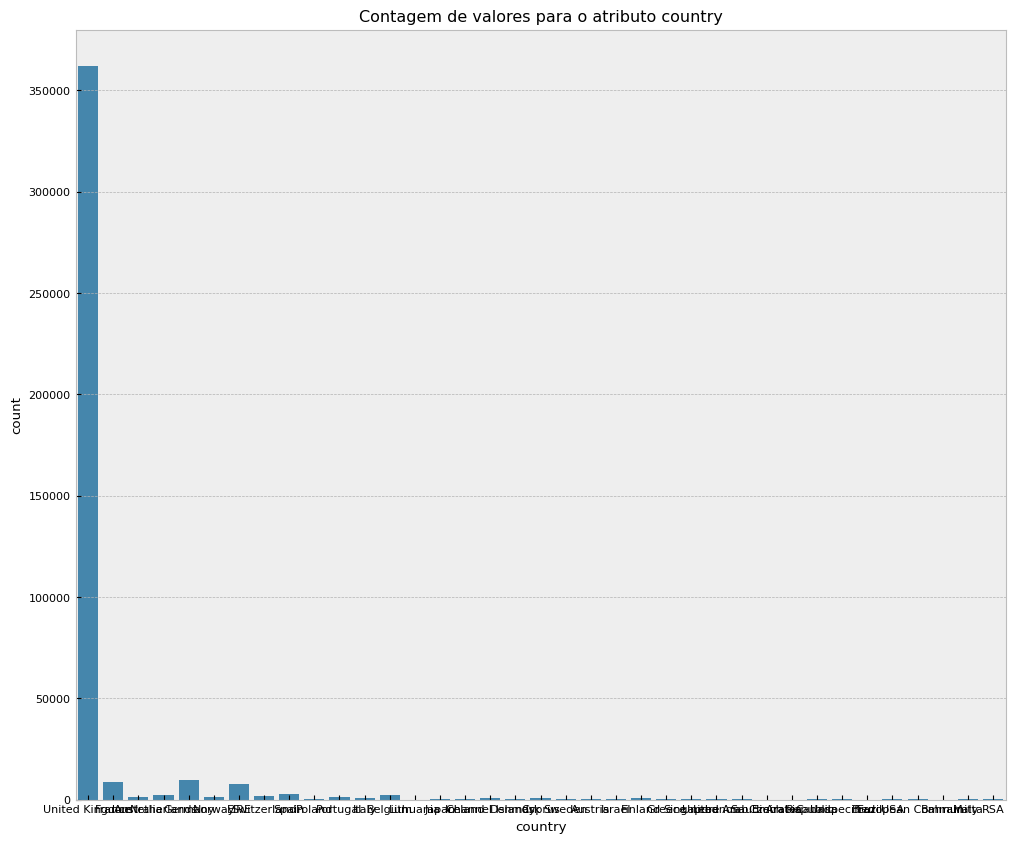

----------------------------------------------------------------



In [45]:
# Domora muito devido a alta volumetria de dados categóricos. Comentei pra não ter que ficar rodando sempre
fs.visualizacao_dados_categoricos(var_cat)

#### 1.4.2.1 invoice_no

In [14]:
invoice_total_cat = len(df_raw.loc[df_raw['invoice_no'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ), 'invoice_no'])
txt_itc = f"Total de valores com caracteres {invoice_total_cat}\n"

invoice_nduplicate_cat = len(df_raw.loc[df_raw['invoice_no'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ), 'invoice_no'].drop_duplicates())
txt_indc = f"Valores com carateres sem duplicados {invoice_nduplicate_cat}\n"

invoice_onlytxt_cat = len(df_raw.loc[df_raw['invoice_no'].apply( lambda x: bool(re.search('^[a-zA-Z]+$', x) ) ), 'invoice_no'].unique())
txt_iotc = f"Valores de carateres só texto {invoice_onlytxt_cat}\n"

print(txt_itc,txt_indc,txt_iotc)

Total de valores com caracteres 8905
 Valores com carateres sem duplicados 3654
 Valores de carateres só texto 0



In [24]:
teste_df_invoice_no = df_raw.loc[(df_raw['invoice_no'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ) ) & (df_raw['quantity'] <= 0)]
print(len(teste_df_invoice_no))
teste_df_invoice_no.sample(10)

8905


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
102729,C545033,22936,BAKING MOULD ROSE WHITE CHOCOLATE,-72,2011-02-25,2.75,14156,EIRE
197003,C553880,21231,SWEETHEART CERAMIC TRINKET BOX,-24,2011-05-19,1.25,13762,United Kingdom
177226,C552049,22081,RIBBON REEL FLORA + FAUNA,-10,2011-05-06,1.65,17548,United Kingdom
86896,C543611,21071,VINTAGE BILLBOARD DRINK ME MUG,-6,2011-02-10,1.06,17850,United Kingdom
327643,C565681,22332,SKULLS PARTY BAG + STICKER SET,-8,2011-09-06,1.65,15521,United Kingdom
156807,C550171,20971,PINK BLUE FELT CRAFT TRINKET BOX,-1,2011-04-14,1.25,12585,Germany
134390,C547838,84949,SILVER HANGING T-LIGHT HOLDER,-6,2011-03-27,1.65,12916,United Kingdom
393491,C570828,90177E,DROP DIAMANTE EARRINGS GREEN,-6,2011-10-12,2.95,14911,EIRE
21746,C538118,22784,LANTERN CREAM GAZEBO,-1,2010-12-09,4.95,17700,United Kingdom
303760,C563554,22467,GUMBALL COAT RACK,-1,2011-08-17,2.55,16755,United Kingdom


Para construir a segmentação de cliente temos que pensar, também nas devoluções, pois isso afeta diretamente o resultado do RFM. A baixo tem uma tabela simplificada com possíveis casos:
| RFM | Devolução | Perfil |
| ----- | ----- | ----- |
| Alta | Alta | Baixa aderência |
| Alta | Baixa | Alta aderência |
| Baixa | Alta | Péssima aderência |
| Baixa | Baixa | Qualificar o cliente |

1. Possui valores categóricos e numéricos.
2. Os valores categóricos aparentemente referem-se a pedidos sem sucesso:
   1. Cancelados, Devolvidos, Modificados?
   2. Possivelmente o valor C antes dos números signifiquem cancelado.
3. Os valores categóricos não possuem similar numérico. Ex.: C521540 ~= 521540. Se existisse similar, poderiamos checar os possíveis insucessos.
   1. Mesmo correlacionando com stock_code, não há um padrão determinado.
4. Foi testado as seguintes combinações invoice_no & quantity para verificar a relação dos sucessos ou insucessos na compra, os resultados foram:
   1. invoice(txt) & quantity >=0 = SEM resultado. Compras com texto não possuem quantidades positivas. Verificar se o texto influencia no sucesso da compra. 
   2. ~invoice(txt) & quantity >=0 = COM resultado. Compras sem texto possuem quantidades positivas. Possivelmente são as compras comums. Possuem 397.924 linhas = 97,81% do df_raw.
   3. invoice(txt) & quantity <=0 = COM resultado. Compras com texto não possuem quantidades positivas. Talvez seja algum tipo de insucesso na compra. Possuem 8.905 linhas = 2,91% do df_raw. 
   4. ~invoice(txt) & quantity <=0 = SEM resultado. Compras sem texto não possuem quantidades positivas. Verificar se o texto influencia no sucesso da compra. 
   5. Conclusão: Aparentemente somente compras de insucesso possuem texto e com quantidades negativas. - `Tratrar, esta bagunçando o cluster`

#### 1.4.2.2 stock_code

In [16]:
stock_code_total_cat = len(df_raw.loc[df_raw['stock_code'].apply( lambda x: bool(re.search('[^0-9]+', x) ) ), 'stock_code'])
print(f"Total de valores com caracteres {stock_code_total_cat}")

stock_code_nduplicate_cat = len(df_raw.loc[df_raw['stock_code'].apply(lambda x: bool( re.search('[^0-9]+', x) ) ), 'stock_code'].drop_duplicates() )
print(f"Valores com carateres sem duplicados {stock_code_nduplicate_cat}")

stock_code_onlytxt_cat = len(df_raw.loc[df_raw['stock_code'].apply(lambda x: bool( re.search('^[a-zA-Z]+', x) ) ), 'stock_code'].unique() )
print(f"Valores de carateres só texto {stock_code_onlytxt_cat}")

stock_code_typetxt_cat = list(df_raw.loc[df_raw['stock_code'].apply(lambda x: bool( re.search('^[a-zA-Z]+', x) ) ), 'stock_code'].unique())
print(f"Lista de valores só caracteres {list(stock_code_typetxt_cat)}")

Total de valores com caracteres 35809
Valores com carateres sem duplicados 886
Valores de carateres só texto 8
Lista de valores só caracteres ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']


In [17]:
len(df_raw.loc[~(df_raw['stock_code'].isin(stock_code_typetxt_cat) ) & (df_raw['quantity'] >= 0) ])

396370

2. stock_code:
   1. O stock code também está com valores categóricos.
   2. Esse valores pertencem a esta lista ['POST', 'D', 'C2', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'CRUK']
   3. Todas as combinações de stock_code (com e sem texto) & (quantity >= ou <= 0) retornaram valores válidos.
      1. Destaco a combinação ~stock_code(in_lista) & quantity >=0. Retorna 396515 valores. Mas o stock_code ainda continha valores numéricos com strings associadas.

#### 1.4.2.3 Description

In [32]:
df_raw['description'].unique().shape

(3896,)

São 3896 produtos distintos:
- Contar caracteres?
- Criar agrupamentos por tipos de produtos?

Primeiro momento deletar description, depois vejo o que faço com ela.

#### 1.4.2.4 Country

In [36]:
print(f"Qtde paises = {df_raw['country'].unique().shape[0]}")
df_raw['country'].unique()

Qtde paises = 37


array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Saudi Arabia', 'Czech Republic', 'Canada',
       'Unspecified', 'Brazil', 'USA', 'European Community', 'Bahrain',
       'Malta', 'RSA'], dtype=object)

In [43]:
df_raw[['country']].value_counts(normalize=True)

country             
United Kingdom         0.8895
Germany                0.0233
France                 0.0209
EIRE                   0.0184
Spain                  0.0062
Netherlands            0.0058
Belgium                0.0051
Switzerland            0.0046
Portugal               0.0036
Australia              0.0031
Norway                 0.0027
Italy                  0.0020
Channel Islands        0.0019
Finland                0.0017
Cyprus                 0.0015
Sweden                 0.0011
Austria                0.0010
Denmark                0.0010
Japan                  0.0009
Poland                 0.0008
USA                    0.0007
Israel                 0.0006
Unspecified            0.0006
Singapore              0.0006
Iceland                0.0004
Canada                 0.0004
Greece                 0.0004
Malta                  0.0003
United Arab Emirates   0.0002
European Community     0.0001
RSA                    0.0001
Lebanon                0.0001
Lithuania          

In [46]:
df_raw[['customer_id','country']].drop_duplicates().groupby('country').count().sort_values(by='customer_id', ascending=False).reset_index().head(5)

,country,customer_id
0,United Kingdom,3950
1,Germany,95
2,France,87
3,Spain,31
4,Belgium,25


# 2.0 Exportar DF

In [44]:
path = "../data/interim/1.descricao.pkl"
fs.save_pickle(obj=df_raw, path=path)